# Mapping Everyday Accessibility: Euclidean vs. Network Distance in Downtown Madison

> How does the lived experience of walking to everyday amenities differ when distance is measured "as-the-crow-flies" versus along the actual street network? This project aims to explore the accessibility of daily facilities in Downtown Madison, Wisconsin.

My research question is: What is the difference between the perceived convenience estimated by simple straight-line (Euclidean) distance and the actual walking experience, which considers the real road network structure (network distance) including city blocks, one-way streets, and pedestrian paths, when traveling from a fixed residential point to nearby food retailers?

To answer this question, I will:

- Construct a detailed pedestrian street network for Downtown Madison using OpenStreetMap data.

- Define a set of key nodes: a fixed "home" location and multiple food retailers (Points of Interest, POIs).

- Calculate and compare the Euclidean and network distances from "home" to each retailer.

- Following the methodology of Xin et al. (2022), explore how network structure affects accessibility through quantitative network analysis (such as closeness centrality).

- Visualize my findings and reflect on the results through a series of charts and interactive maps.



In [1]:
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import folium
import osmnx as ox
import networkx as nx
from geopy.distance import geodesic
from shapely.geometry import Point, Polygon
import warnings
warnings.filterwarnings('ignore')

## Network Construction & Nodes of Interest

To simulate a realistic walking environment, I used the osmnx library to retrieve the pedestrian street network for downtown Madison from OpenStreetMap (OSM). This network is a graph composed of "nodes" (intersections or path endpoints) and "edges" (streets or sidewalks connecting the nodes).

Key Nodes
My analysis centers on two types of key nodes:

- Anchor Point (Home): I set a fixed geographic coordinate as my starting point and found the nearest node in the street network to serve as the "home node."

- Retail Nodes (POIs): I identified the locations of 23 food retailers and found the nearest network node for each one.

These nodes form the origins and destinations for my distance measurements.

In [2]:
HOME_COORDS = (43.071780, -89.393726)
BBOX = {'north': 43.090, 'south': 43.054, 'east': -89.375, 'west': -89.412}
WALKING_SPEED_KPH = 5.0

In [3]:
restaurants_gdf = gpd.read_file('madison_food_pois.geojson')

In [4]:
euclidean_distances = []
for idx, restaurant in restaurants_gdf.iterrows():
    distance = geodesic(HOME_COORDS, (restaurant.geometry.y, restaurant.geometry.x)).meters
    euclidean_distances.append(distance)

# Euclidean Distance
restaurants_gdf['euclidean_distance_m'] = euclidean_distances
restaurants_gdf['euclidean_time_min'] = restaurants_gdf['euclidean_distance_m'] / (WALKING_SPEED_KPH * 1000 / 60)

## Distance Calculation: The Straight Line vs. Reality
I calculated two types of distances:

- Euclidean Distance: The straight-line distance from "home" to each retailer, i.e., "as-the-crow-flies." This is a quick but potentially unrealistic estimate.

- Network Distance: The shortest path distance along the pedestrian network, calculated using Dijkstra's algorithm. This more closely represents the actual walking experience.

In [5]:
graph = ox.graph_from_place("Madison, Wisconsin, USA", network_type='walk', simplify=True)

buffer = 0.009
expanded_poly = Polygon([(BBOX['west'] - buffer, BBOX['south'] - buffer),
                        (BBOX['east'] + buffer, BBOX['south'] - buffer),
                        (BBOX['east'] + buffer, BBOX['north'] + buffer),
                        (BBOX['west'] - buffer, BBOX['north'] + buffer)])

nodes_gdf = ox.graph_to_gdfs(graph, edges=False)
nodes_in_area = nodes_gdf[nodes_gdf.geometry.within(expanded_poly)]
street_network = graph.subgraph(nodes_in_area.index).copy()

for u, v, d in street_network.edges(data=True):
    length = d.get('length', 0)
    d['travel_time'] = length / (WALKING_SPEED_KPH * 1000 / 3600)

In [6]:
home_node = ox.nearest_nodes(street_network, HOME_COORDS[1], HOME_COORDS[0])
travel_times = nx.single_source_dijkstra_path_length(street_network, home_node, weight='travel_time')

network_distances = []
network_times = []

for idx, restaurant in restaurants_gdf.iterrows():
    restaurant_node = ox.nearest_nodes(street_network, restaurant.geometry.x, restaurant.geometry.y)
    if restaurant_node in travel_times:
        travel_time_sec = travel_times[restaurant_node]
        network_distance_m = travel_time_sec * (WALKING_SPEED_KPH * 1000 / 3600)
        network_distances.append(network_distance_m)
        network_times.append(travel_time_sec / 60)
    else:
        network_distances.append(np.nan)
        network_times.append(np.nan)

restaurants_gdf['network_distance_m'] = network_distances
restaurants_gdf['network_time_min'] = network_times
reachable_restaurants = restaurants_gdf.dropna(subset=['network_distance_m'])

## Reflection on the Results

The charts below visually demonstrate the differences between the two distance measurement methods:

- **Network Distance is Always Longer**: In the two scatter plots on the left, all data points lie above the red 1:1 diagonal line. This confirms the intuitive conclusion that the actual walking distance is always greater than the straight-line distance due to the obstruction of city blocks.

- **The "Detour Factor"**: The histogram in the upper right shows the distribution of the 'Network Distance / Euclidean Distance' ratio. For most retailers, this ratio is concentrated between 1.2 and 1.3, meaning I need to walk 20% to 30% farther than the straight-line distance to reach them. For some points, this ratio is as high as 1.7, indicating these locations are significantly isolated by the network structure.

- **The Additional Time Cost**: The histogram in the lower right translates this difference into time. For most destinations, I need to spend an additional 1 to 4 minutes walking. This seemingly small difference can accumulate and have a significant impact on daily travel decisions, especially in bad weather or when time is tight.

These charts quantify the experiential difference between "what looks close" on a map and "how long it actually takes to walk."

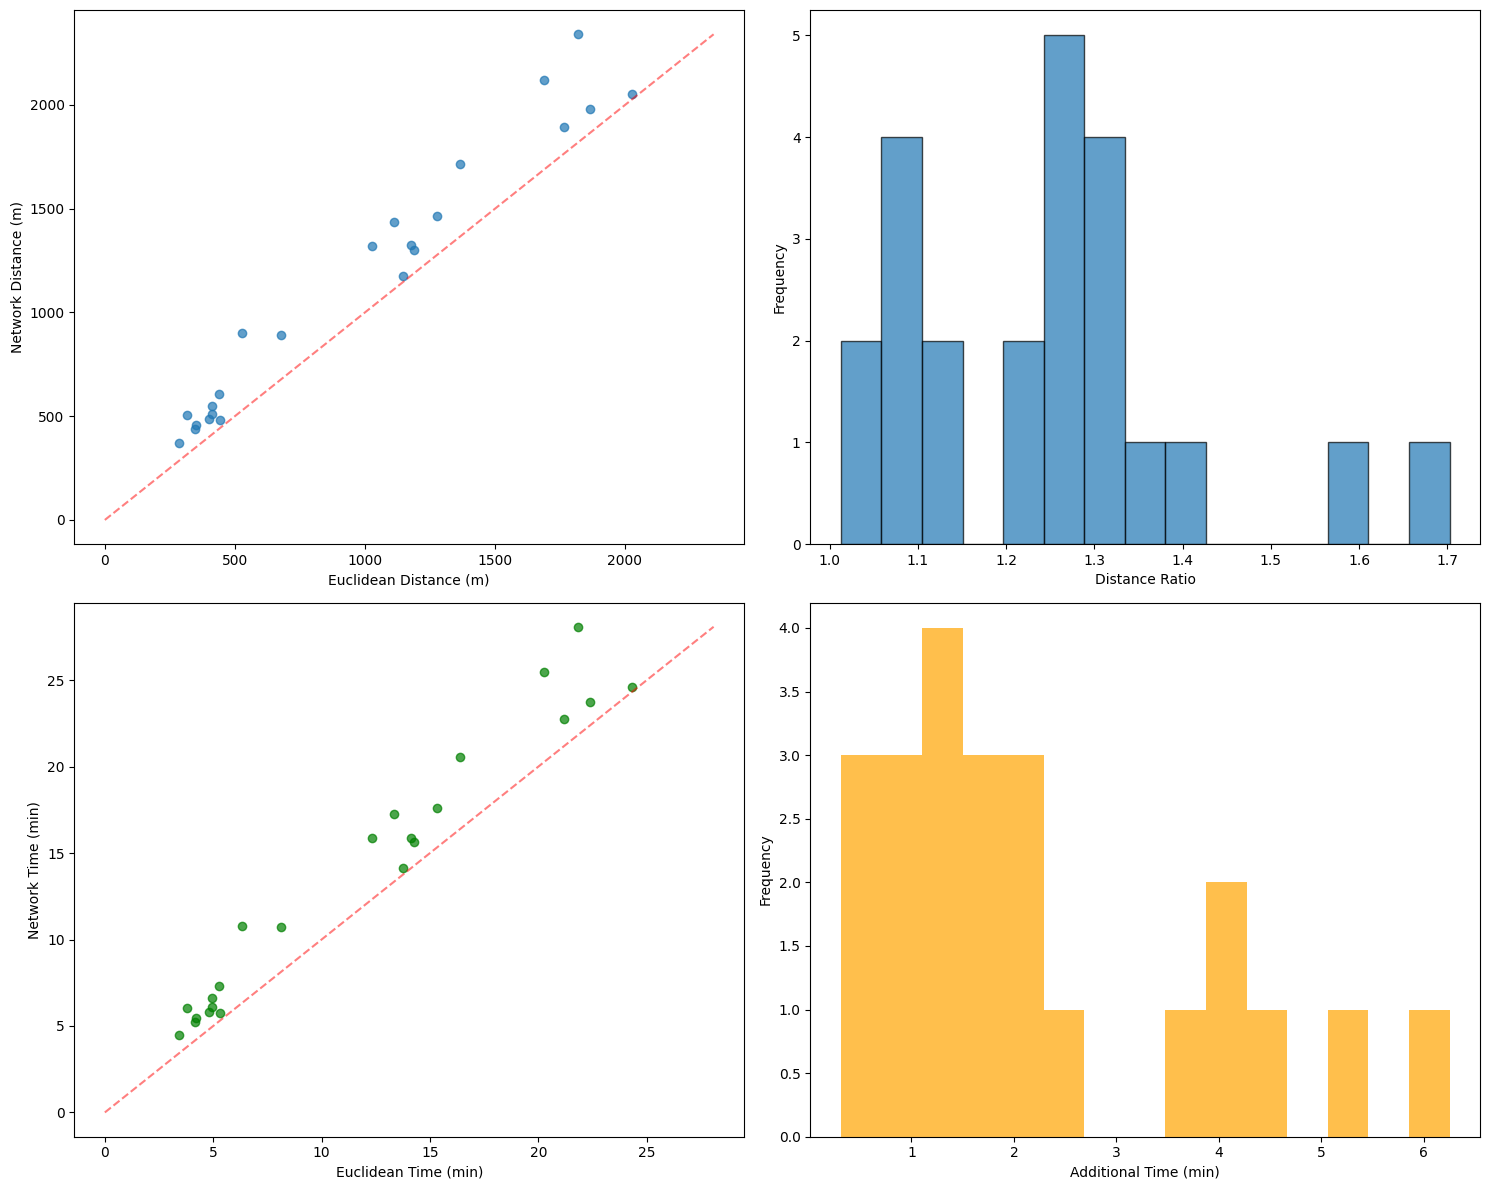

In [7]:
reachable_restaurants['distance_ratio'] = reachable_restaurants['network_distance_m'] / reachable_restaurants['euclidean_distance_m']

fig, axes = plt.subplots(2, 2, figsize=(15, 12))

axes[0,0].scatter(reachable_restaurants['euclidean_distance_m'], reachable_restaurants['network_distance_m'], alpha=0.7)
max_dist = max(reachable_restaurants['euclidean_distance_m'].max(), reachable_restaurants['network_distance_m'].max())
axes[0,0].plot([0, max_dist], [0, max_dist], 'r--', alpha=0.5)
axes[0,0].set_xlabel('Euclidean Distance (m)')
axes[0,0].set_ylabel('Network Distance (m)')

axes[0,1].hist(reachable_restaurants['distance_ratio'], bins=15, alpha=0.7, edgecolor='black')
axes[0,1].set_xlabel('Distance Ratio')
axes[0,1].set_ylabel('Frequency')

axes[1,0].scatter(reachable_restaurants['euclidean_time_min'], reachable_restaurants['network_time_min'], alpha=0.7, color='green')
max_time = max(reachable_restaurants['euclidean_time_min'].max(), reachable_restaurants['network_time_min'].max())
axes[1,0].plot([0, max_time], [0, max_time], 'r--', alpha=0.5)
axes[1,0].set_xlabel('Euclidean Time (min)')
axes[1,0].set_ylabel('Network Time (min)')

axes[1,1].hist(reachable_restaurants['network_time_min'] - reachable_restaurants['euclidean_time_min'], bins=15, alpha=0.7, color='orange')
axes[1,1].set_xlabel('Additional Time (min)')
axes[1,1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()


## Closeness Centrality Analysis

To understand the network structure more deeply, I calculated the Closeness Centrality for each retailer node. This metric measures the average distance from a node to all other nodes in the network. A higher centrality score indicates that a node is more central, and it's easier to get to any other place from that node.

The chart below reveals some interesting patterns:

- **The Trade-off between Distance and Centrality**: The scatter plot on the left shows a general negative correlation between network distance and closeness centrality. The retailers closest to home (network distance < 500m) generally have the highest centrality scores. This means they are not only close to home but also centrally located in the transportation network, making it equally convenient to travel from these points to other parts of the network.

- **The Distribution of Centrality**: The histogram on the right shows that most retailers' centrality scores are concentrated in a high range (0.00070 - 0.00080). This suggests that the retail network in the downtown core is quite well-integrated. However, there are some low-scoring outliers, which are typically the stores that are farther away in terms of network distance and located on the periphery of the network.

This analysis tells me that the "good location" of a retailer depends not only on its distance from a specific point (like home) but also on its degree of integration within the entire city network.

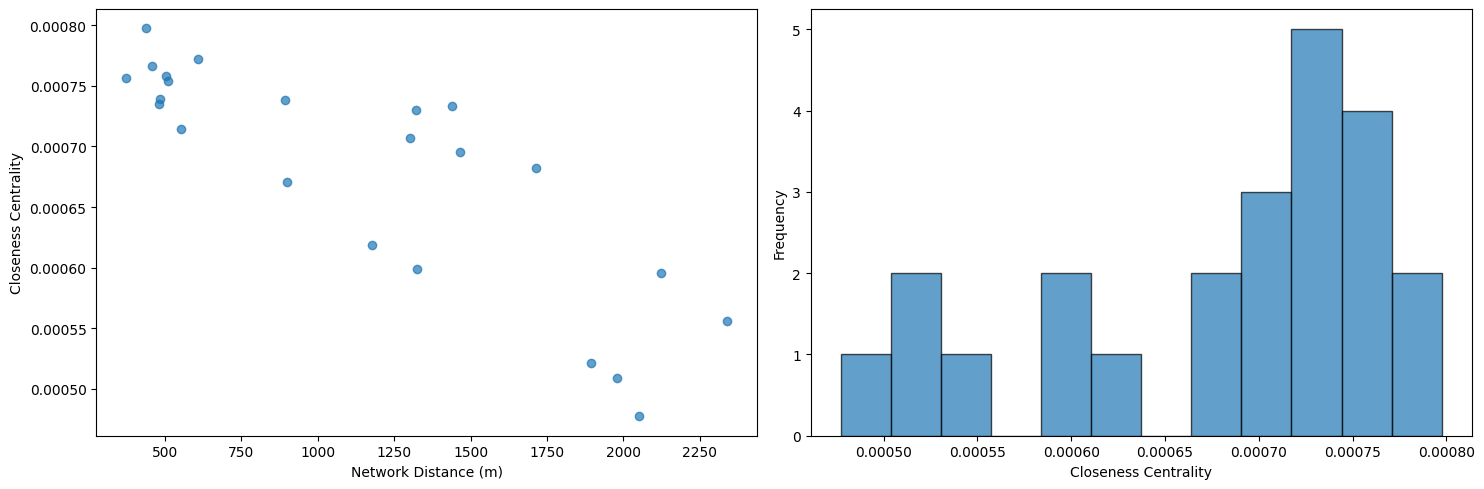

In [8]:
centrality_scores = []
for idx, restaurant in reachable_restaurants.iterrows():
    restaurant_node = ox.nearest_nodes(street_network, restaurant.geometry.x, restaurant.geometry.y)
    distances = nx.single_source_dijkstra_path_length(street_network, restaurant_node, weight='travel_time')
    cc_score = (len(distances) - 1) / sum(distances.values()) if sum(distances.values()) > 0 else 0
    centrality_scores.append(cc_score)

reachable_restaurants['closeness_centrality'] = centrality_scores

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

ax1.scatter(reachable_restaurants['network_distance_m'], reachable_restaurants['closeness_centrality'], alpha=0.7)
ax1.set_xlabel('Network Distance (m)')
ax1.set_ylabel('Closeness Centrality')

ax2.hist(centrality_scores, bins=12, alpha=0.7, edgecolor='black')
ax2.set_xlabel('Closeness Centrality')
ax2.set_ylabel('Frequency')

plt.tight_layout()
plt.show()


## Integrated Map & Conclusion

Finally, I integrated all the analysis results into a single interactive map. This map not only marks the home and all retailer locations but also plots the shortest walking paths from home to the three retailers with the highest closeness centrality.

**Key Information on the Map**:

- Icon Color: Represents the type of retailer (e.g., supermarket, convenience store).

- Popup Window: Clicking on any retailer icon will display its name, Euclidean distance, network distance, and closeness centrality score.

- Paths: The highlighted paths reveal the actual streets one needs to take to reach the most central and convenient retailers in the network.


## Final Reflection
Through this analysis, I have quantified and visualized two perspectives on walking accessibility in downtown Madison. I found that relying solely on straight-line distance significantly underestimates the actual travel cost. Furthermore, by introducing the concept of network centrality, I were able to identify "prime locations" that are not only close in distance but also strategically better positioned within the entire walking network. This integrated approach, combining distance and network structure, provides a more profound perspective for understanding urban space and the daily experiences of its residents.

In [9]:
m = folium.Map(location=HOME_COORDS, zoom_start=14)

folium.Marker(HOME_COORDS, popup='Home', icon=folium.Icon(color='red', icon='home')).add_to(m)

color_map = {'supermarket': 'green', 'grocery': 'blue', 'organic': 'purple', 'convenience': 'orange', 'other': 'gray'}

for idx, restaurant in reachable_restaurants.iterrows():
    color = color_map.get(restaurant['store_type'], 'gray')
    popup_content = f"{restaurant['name']}<br/>Euclidean: {restaurant['euclidean_distance_m']:.0f}m<br/>Network: {restaurant['network_distance_m']:.0f}m<br/>Centrality: {restaurant['closeness_centrality']:.6f}"
    folium.Marker([restaurant.geometry.y, restaurant.geometry.x], popup=popup_content, icon=folium.Icon(color=color)).add_to(m)

home_node = ox.nearest_nodes(street_network, HOME_COORDS[1], HOME_COORDS[0])
most_central = reachable_restaurants.nlargest(3, 'closeness_centrality')
colors = ['blue', 'green', 'purple']

for i, (idx, restaurant) in enumerate(most_central.iterrows()):
    try:
        restaurant_node = ox.nearest_nodes(street_network, restaurant.geometry.x, restaurant.geometry.y)
        path = nx.shortest_path(street_network, home_node, restaurant_node, weight='travel_time')
        path_coords = [[street_network.nodes[node]['y'], street_network.nodes[node]['x']] for node in path]
        folium.PolyLine(path_coords, color=colors[i], weight=4, opacity=0.8).add_to(m)
    except: pass

m.save("5_Network_Analysis.html")
m
